# Study 257 -- AAII-Sentiment
## For the quants: regime sort, HAC regression, timing overlay, sub-periods, positive control

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from aaii_sentiment import data, strategy as st

GSPC_CACHE = data.GSPC_CACHE
HAVE_REAL = os.path.exists(GSPC_CACHE)

if HAVE_REAL:
    panel = data.build_real_panel(fetch=False)
    reg_sum = st.regime_summary(panel)
    contra = st.regime_spread(panel)
    regr = st.predictive_regression(panel)
    print(f"Real tape: {len(panel)} months  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Fingerprint(spread): {data.fingerprint(panel)}")
else:
    panel = reg_sum = contra = regr = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")


Real tape: 182 months  1987-08-31 -> 2026-05-31
Fingerprint(spread): 714da328c0fd


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 182, 'start': '1987-08', 'end': '2026-05', 'fingerprint': '714da328c0fd', 'low_ann': 23.85, 'low_t': 2.24, 'low_n': 61, 'mid_ann': 4.76, 'mid_t': 0.62, 'mid_n': 55, 'high_ann': 8.52, 'high_t': 1.78, 'high_n': 66, 'low_minus_high_pp': 15.33, 'contra_t': 1.18, 'contra_n': 182, 'reg_beta_pct': -0.66, 'reg_t': -1.54, 'reg_r2': 0.018, 'overlay_net_ann': 9.25, 'overlay_t': 2.23, 'bh_ann': 12.52, 's1_lab': '1987-1999', 's1_low': 21.3, 's1_high': 15.5, 's1_lowt': 1.07, 's1_n': 55, 's2_lab': '2000-2012', 's2_low': 18.7, 's2_high': 3.2, 's2_lowt': 0.8, 's2_n': 62, 's3_lab': '2013-2026', 's3_low': 33.8, 's3_high': 7.8, 's3_lowt': 2.26, 's3_n': 65, 'syn_beta_t': -2.99, 'syn_null_t': -0.2}


## Positive control: the engine detects a planted contrarian edge

Before touching the real tape we confirm the machinery is truthful. The
synthetic generator plants a *known* contrarian loading (`edge`): next-month
return loads negatively on the current spread. The predictive regression must
recover a negative slope when the edge is planted and ~zero when it is not.


In [3]:
def to_panel(df):
    p = df.copy(); p["ret"] = df["ret"].shift(-1); return p.dropna()

df_edge, truth = data.synthetic_monthly(edge=0.06, seed=257)
reg_e = st.predictive_regression(to_panel(df_edge))
print(f"Synthetic edge=0.06:  beta = {reg_e['beta']*100:+.3f} %/sd   HAC t = {reg_e['tstat']:+.2f}   r2 = {reg_e['r2']:.3f}")

df_null, _ = data.synthetic_monthly(edge=0.0, seed=257)
reg_n = st.predictive_regression(to_panel(df_null))
print(f"Synthetic null  =0.00:  beta = {reg_n['beta']*100:+.3f} %/sd   HAC t = {reg_n['tstat']:+.2f}")
print("-> Engine recovers the planted negative (contrarian) slope and reads ~zero on the null.")


Synthetic edge=0.06:  beta = -0.727 %/sd   HAC t = -2.99   r2 = 0.025
Synthetic null  =0.00:  beta = -0.048 %/sd   HAC t = -0.20
-> Engine recovers the planted negative (contrarian) slope and reads ~zero on the null.


## The regime sort: next-month return by prior sentiment tercile

In [4]:
if HAVE_REAL:
    print(reg_sum.to_string(float_format=lambda v: f"{v:+.4f}"))
    lo = reg_sum.loc["low"]; hi = reg_sum.loc["high"]
    print()
    print(f"LOW  (panic)    : {lo['mean_ann']*100:+.1f}%/yr  HAC t={lo['tstat']:+.2f}  n={int(lo['n'])}")
    print(f"HIGH (euphoria) : {hi['mean_ann']*100:+.1f}%/yr  HAC t={hi['tstat']:+.2f}  n={int(hi['n'])}")
    print(f"low-minus-high  : {(lo['mean_ann']-hi['mean_ann'])*100:+.1f} pp/yr")
else:
    print(f"Frozen: low={R['low_ann']:+.1f}%/yr (t={R['low_t']:+.2f}), high={R['high_ann']:+.1f}%/yr (t={R['high_t']:+.2f})")
    print(f"low-minus-high: {R['low_minus_high_pp']:+.1f} pp/yr")
print("\nThe LOW-sentiment regime is the only one near significance -- panic pays, but euphoria")
print("is not a reliable SELL (high-sentiment months still average a positive return).")


         n  mean_mo  mean_ann   tstat
regime                               
low     61  +0.0199   +0.2385 +2.2448
mid     55  +0.0040   +0.0476 +0.6248
high    66  +0.0071   +0.0852 +1.7782

LOW  (panic)    : +23.8%/yr  HAC t=+2.24  n=61
HIGH (euphoria) : +8.5%/yr  HAC t=+1.78  n=66
low-minus-high  : +15.3 pp/yr

The LOW-sentiment regime is the only one near significance -- panic pays, but euphoria
is not a reliable SELL (high-sentiment months still average a positive return).


## Headline long-short test + predictive regression (HAC)

In [5]:
if HAVE_REAL:
    s_contra = st.summarize(contra)
    print("=== Contrarian long-short (long panic / short euphoria) ===")
    print(f"  mean = {s_contra['mean']*1200:+.2f}%/yr   HAC t = {s_contra['tstat']:+.2f}   n = {s_contra['n']}")
    print()
    print("=== Predictive regression: ret_(t+1) ~ standardised prior spread ===")
    print(f"  beta = {regr['beta']*100:+.3f} %/sd   HAC t = {regr['tstat']:+.2f}   r2 = {regr['r2']:.4f}   n = {regr['n']}")
else:
    print(f"Frozen: contrarian long-short HAC t = {R['contra_t']:+.2f} (n={R['contra_n']})")
    print(f"Frozen: regression beta = {R['reg_beta_pct']:+.2f}%/sd  HAC t = {R['reg_t']:+.2f}  r2 = {R['reg_r2']:.3f}")
print("\nThe slope sign is correct (NEGATIVE = contrarian) but |t| < 2: WEAK, not REAL.")
print("R-squared ~2%: sentiment explains almost none of next-month variance.")


=== Contrarian long-short (long panic / short euphoria) ===
  mean = +4.90%/yr   HAC t = +1.20   n = 182

=== Predictive regression: ret_(t+1) ~ standardised prior spread ===
  beta = -0.660 %/sd   HAC t = -1.54   r2 = 0.0177   n = 182

The slope sign is correct (NEGATIVE = contrarian) but |t| < 2: WEAK, not REAL.
R-squared ~2%: sentiment explains almost none of next-month variance.


## Timing overlay vs buy-and-hold (price-only, net of costs)

Long/flat contrarian overlay (sit out euphoric months), 5bps one-way:
  Overlay NET : +9.25%/yr  vol=15.7%  SR=+0.59  t=+2.23
  Buy & hold  : +12.52%/yr  vol=17.2%  SR=+0.73
  Net of costs the overlay LOSES TO buy-and-hold.


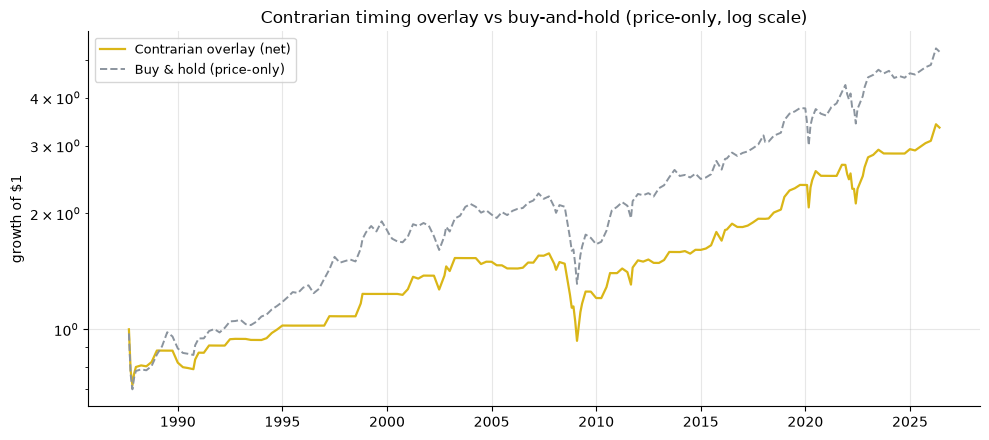


Sitting out euphoria means missing the meat of bull markets: the overlay UNDERPERFORMS.


In [6]:
if HAVE_REAL:
    ov = st.timing_overlay(panel, allow_short=False, one_way_bps=5.0)
    s_net = st.summarize(ov["net"]); s_bh = st.summarize(ov["bh"])
    print("Long/flat contrarian overlay (sit out euphoric months), 5bps one-way:")
    print(f"  Overlay NET : {s_net['mean']*1200:+.2f}%/yr  vol={s_net['vol']*np.sqrt(12)*100:.1f}%  SR={s_net['sharpe']*12**0.5:+.2f}  t={s_net['tstat']:+.2f}")
    print(f"  Buy & hold  : {s_bh['mean']*1200:+.2f}%/yr  vol={s_bh['vol']*np.sqrt(12)*100:.1f}%  SR={s_bh['sharpe']*12**0.5:+.2f}")
    print(f"  Net of costs the overlay {'BEATS' if s_net['mean']>s_bh['mean'] else 'LOSES TO'} buy-and-hold.")

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot((1+ov['net']).cumprod().index, (1+ov['net']).cumprod().values, color=AMBER, lw=1.6, label="Contrarian overlay (net)")
    ax.plot((1+ov['bh']).cumprod().index, (1+ov['bh']).cumprod().values, color=GREY, lw=1.4, ls="--", label="Buy & hold (price-only)")
    ax.set_yscale("log"); ax.set_title("Contrarian timing overlay vs buy-and-hold (price-only, log scale)")
    ax.set_ylabel("growth of $1"); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig("../docs/overlay.png", dpi=120, bbox_inches="tight"); plt.show()
else:
    print(f"Frozen: overlay net = {R['overlay_net_ann']:+.1f}%/yr (t={R['overlay_t']:+.2f})  vs buy-and-hold {R['bh_ann']:+.1f}%/yr")
print("\nSitting out euphoria means missing the meat of bull markets: the overlay UNDERPERFORMS.")


## Sub-periods: the direction is stable, the significance is not

In [7]:
if HAVE_REAL:
    for lab, a, b in [("1987-1999","1987","1999"), ("2000-2012","2000","2012"), ("2013-2026","2013","2026")]:
        sub = panel[a:b]; rs = st.regime_summary(sub)
        print(f"  {lab}: low={rs.loc['low','mean_ann']*100:+.1f}%/yr (t={rs.loc['low','tstat']:+.2f})  "
              f"high={rs.loc['high','mean_ann']*100:+.1f}%/yr  n={len(sub)}")
else:
    for lab, lo, hi, lt, n in [
        (R['s1_lab'], R['s1_low'], R['s1_high'], R['s1_lowt'], R['s1_n']),
        (R['s2_lab'], R['s2_low'], R['s2_high'], R['s2_lowt'], R['s2_n']),
        (R['s3_lab'], R['s3_low'], R['s3_high'], R['s3_lowt'], R['s3_n']),
    ]:
        print(f"  {lab}: low={lo:+.1f}%/yr (t={lt:+.2f})  high={hi:+.1f}%/yr  n={n}")
print("\nLow > high in EVERY sub-period (direction robust), but the low-regime t-stat only")
print("clears 2 in the most recent slice -- and on a curated, revised sentiment snapshot.")


  1987-1999: low=+21.3%/yr (t=+1.07)  high=+15.5%/yr  n=55
  2000-2012: low=+18.7%/yr (t=+0.80)  high=+3.2%/yr  n=62


  2013-2026: low=+33.8%/yr (t=+2.26)  high=+7.8%/yr  n=65

Low > high in EVERY sub-period (direction robust), but the low-regime t-stat only
clears 2 in the most recent slice -- and on a curated, revised sentiment snapshot.


## Verdict

In [8]:
print("=== Study 257 -- AAII-Sentiment ===")
print()
print(f"Signal: WEAK")
print(f"  Direction correct (panic -> +{R['low_ann']:.0f}%/yr vs euphoria +{R['high_ann']:.0f}%/yr, stable across sub-periods)")
print(f"  BUT headline long-short HAC t = {R['contra_t']:+.2f} and regression slope t = {R['reg_t']:+.2f} (<2)")
print(f"  R-squared ~{R['reg_r2']*100:.0f}%; signal is curated/revised monthly, not point-in-time weekly")
print()
print(f"Tradability: MIRAGE")
print(f"  Long/flat overlay nets {R['overlay_net_ann']:+.0f}%/yr -- BELOW buy-and-hold {R['bh_ann']:+.0f}%/yr")
print(f"  Euphoria coincides with bull markets you cannot afford to skip")
print(f"  Edge concentrated in a few violent rebounds (2009, 2020) visible only ex post")
print()
print("Vintage/survivorship: NAMED -- curated monthly snapshot is an upper bound on the live weekly edge")
print()
print("Bottom line: Weak/Mirage -- a directionally-real contrarian tilt that fails the")
print("  t>=2 bar and loses to buy-and-hold once you actually have to trade it.")


=== Study 257 -- AAII-Sentiment ===

Signal: WEAK
  Direction correct (panic -> +24%/yr vs euphoria +9%/yr, stable across sub-periods)
  BUT headline long-short HAC t = +1.18 and regression slope t = -1.54 (<2)
  R-squared ~2%; signal is curated/revised monthly, not point-in-time weekly

Tradability: MIRAGE
  Long/flat overlay nets +9%/yr -- BELOW buy-and-hold +13%/yr
  Euphoria coincides with bull markets you cannot afford to skip
  Edge concentrated in a few violent rebounds (2009, 2020) visible only ex post

Vintage/survivorship: NAMED -- curated monthly snapshot is an upper bound on the live weekly edge

Bottom line: Weak/Mirage -- a directionally-real contrarian tilt that fails the
  t>=2 bar and loses to buy-and-hold once you actually have to trade it.
